| Technology               | Overnight Cost | Unit    | FOM [%/yr] | Lifetime [years] | Efficiency | Source               |
| ------------------------ | -------------- | ------- | ---------- | ---------------- | ---------- | -------------------- |
| Onshore Wind             | 910            | €/kW_el | 3.3        | 30               | –          | Danish Energy Agency |
| Offshore Wind            | 2506           | €/kW_el | 3          | 25               | –          | Danish Energy Agency |
| Solar PV (utility-scale) | 425            | €/kW_el | 3          | 25               | –          | Danish Energy Agency |
| OCGT                     | 560            | €/kW_el | 3.3        | 25               | 0.39       | Danish Energy Agency |
| Coal (supercritical)     | 2133           | $/kW_el | –          | 40               | 0.41       | OECD/IEA             |
| Nuclear (Gen III)        | 4101           | $/kW_el | –          | 60               | 0.33       | OECD/IEA             |


Danish Energy Agency – Technology Data for Electricity Generation (used in many European energy system models).
**OECD Nuclear Energy Agency / International Energy Agency – Projected Costs of Generating Electricity.

In [1]:
import pandas as pd
pd.set_option("future.infer_string", False)   # ← add this line

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa
import warnings
warnings.filterwarnings("ignore")

In [2]:
def annuity(n, r):
    """Annuity factor for asset with lifetime n years and discount rate r."""
    if r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** n)
    else:
        return 1.0 / n

In [3]:
print("Loading data...")
df = pd.read_csv("data.csv", parse_dates=["cet_cest_timestamp"])
df = df.set_index("cet_cest_timestamp")
df = df.apply(pd.to_numeric, errors="coerce")
# Filter to 2017
df_2017 = df[df.index.year == 2017].copy()

# Drop rows where load is 0 or NaN (artefacts at midnight boundary)
df_2017 = df_2017[df_2017["load"] > 0].copy()

# Remove duplicate timestamps (caused by DST clock changes in Germany:
# clocks go back 1 h in October, producing a repeated hour in local time)
df_2017 = df_2017[~df_2017.index.duplicated(keep="first")]

# Build a complete hourly index for 2017 and reindex (forward-fill tiny gaps)
hours_2017 = pd.date_range("2017-01-01 00:00", "2017-12-31 23:00", freq="h")
df_2017 = df_2017.reindex(hours_2017).interpolate(method="time")


print(f"  Snapshots: {len(df_2017)} hours")
print(f"  Load range: {df_2017['load'].min():.0f} – {df_2017['load'].max():.0f} MW")

# Capacity-factor profiles (0–1).  Column names follow the data.csv schema.
cf_onshore  = df_2017["Wind_Onshore Profile"].clip(0, 1)
cf_offshore = df_2017["Wind_Offshore Profile"].clip(0, 1)
cf_solar    = df_2017["Solar Profile"].clip(0, 1)

Loading data...
  Snapshots: 8760 hours
  Load range: 33835 – 77549 MW


In [ ]:
# ── 3. Cost parameters ────────────────────────────────────────────────────────
r        = 0.07        # discount rate
usd_eur  = 1 / 1.13   # 2017 average ECB rate  → USD → EUR


#DATA FROM DAWID#

# Capital costs  [€/MW] = overnight_cost [€/kW] * 1000 * annuity * (1 + FOM)
cap_onshore  = annuity(30, r) * 910000  * (1 + 0.033)   # DEA
cap_offshore = annuity(25, r) * 2506000 * (1 + 0.030)  # DEA
cap_solar    = annuity(25, r) * 425000  * (1 + 0.030)   # DEA
cap_ocgt     = annuity(25, r) * 560000  * (1 + 0.033)   # DEA
cap_coal     = annuity(40, r) * 2133000 * usd_eur       # OECD/IEA (no FOM listed → included in fuel/VOM)
cap_nuclear  = annuity(60, r) * 4101000 * usd_eur       # OECD/IEA

# Marginal (fuel) costs  [€/MWh_el] = fuel_cost / efficiency
fuel_gas     = 21.6   # €/MWh_th  (IEA Gas Market Report 2017)
fuel_coal    = 8.5    # €/MWh_th  (IEA Coal 2017 hard-coal import price)
fuel_nuclear = 3.5    # €/MWh_th  (IEA / typical EU nuclear fuel cost)

eff_ocgt    = 0.39
eff_coal    = 0.41
eff_nuclear = 0.33

mc_ocgt    = fuel_gas     / eff_ocgt
mc_coal    = fuel_coal    / eff_coal
mc_nuclear = fuel_nuclear / eff_nuclear

# VOM (variable O&M) additions  [€/MWh_el] — typical values
vom_coal    = 4.0   # €/MWh_el
vom_nuclear = 12.0  # €/MWh_el  (includes decommissioning provision)

mc_coal    += vom_coal
mc_nuclear += vom_nuclear

#DATA FROM 2030#

# Battery storage assumptions from DEA data
battery_max_hours = 2

battery_inverter_investment = 	169.3155 * 1000   # EUR/kW -> 2020 prices: EUR/MW (285.7198)
battery_storage_investment  = 150.2675 * 1000   # EUR/kWh -> 2020 prices EUR/MWh (245.5074)

battery_inverter_fom = 	0.3375 / 100
battery_inverter_lifetime = 10
battery_storage_lifetime = 25.0

battery_inverter_capital_cost = (
    annuity(battery_inverter_lifetime, r)
    * battery_inverter_investment
    * (1 + battery_inverter_fom)
)

battery_storage_capital_cost = battery_storage_investment * (
    annuity(battery_storage_lifetime, r) 
)

battery_efficiency = 0.96   

battery_capital_cost = (
    battery_inverter_capital_cost
    + battery_max_hours * battery_storage_capital_cost
)

print("\nAnnualised capital costs [€/MW/yr]:")
print(f"  Onshore wind : {cap_onshore:,.0f}")
print(f"  Offshore wind: {cap_offshore:,.0f}")
print(f"  Solar PV     : {cap_solar:,.0f}")
print(f"  OCGT         : {cap_ocgt:,.0f}")
print(f"  Coal         : {cap_coal:,.0f}")
print(f"  Nuclear      : {cap_nuclear:,.0f}")
print("\nMarginal costs [€/MWh_el]:")
print(f"  OCGT    : {mc_ocgt:.2f}")
print(f"  Coal    : {mc_coal:.2f}")
print(f"  Nuclear : {mc_nuclear:.2f}")


Annualised capital costs [€/MW/yr]:
  Onshore wind : 75,754
  Offshore wind: 221,492
  Solar PV     : 37,564
  OCGT         : 49,640
  Coal         : 141,588
  Nuclear      : 258,505

Marginal costs [€/MWh_el]:
  OCGT    : 55.38
  Coal    : 24.73
  Nuclear : 22.61


In [25]:
# ── 4. Build PyPSA network ────────────────────────────────────────────────────
print("\nBuilding PyPSA network...")
n = pypsa.Network()
n.set_snapshots(hours_2017)

n.add("Bus", "DE electricity")

# Carriers
n.add("Carrier", "onshorewind")
n.add("Carrier", "offshorewind")
n.add("Carrier", "solar")
n.add("Carrier", "gas",     co2_emissions=0.19)   # tCO2/MWh_th
n.add("Carrier", "coal",    co2_emissions=0.34)   # tCO2/MWh_th
n.add("Carrier", "nuclear", co2_emissions=0.0)
n.add("Carrier", "battery", co2_emissions=0.0)

# Load
n.add("Load", "demand",
      bus="DE electricity",
      p_set=df_2017["load"].values)

# Onshore Wind
n.add("Generator", "Onshore Wind",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="onshorewind",
      capital_cost=cap_onshore,
      marginal_cost=0,
      p_max_pu=cf_onshore.values)

# Offshore Wind
n.add("Generator", "Offshore Wind",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="offshorewind",
      capital_cost=cap_offshore,
      marginal_cost=0,
      p_max_pu=cf_offshore.values)

# Solar PV
n.add("Generator", "Solar PV",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="solar",
      capital_cost=cap_solar,
      marginal_cost=0,
      p_max_pu=cf_solar.values)

# OCGT
n.add("Generator", "OCGT",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="gas",
      capital_cost=cap_ocgt,
      marginal_cost=mc_ocgt,
      efficiency=eff_ocgt)

# Coal
n.add("Generator", "Coal",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="coal",
      capital_cost=cap_coal,
      marginal_cost=mc_coal,
      efficiency=eff_coal)

# Nuclear
n.add("Generator", "Nuclear",
      bus="DE electricity",
      p_nom_extendable=True,
      carrier="nuclear",
      capital_cost=cap_nuclear,
      marginal_cost=mc_nuclear,
      efficiency=eff_nuclear)
# Battery storage
n.add(
    "StorageUnit",
    "battery",
    bus="DE electricity",
    carrier="battery",
    max_hours=battery_max_hours,
    capital_cost=battery_capital_cost,
    efficiency_store=battery_efficiency,
    efficiency_dispatch=battery_efficiency,
    p_nom_extendable=True,
    cyclic_state_of_charge=True)



Building PyPSA network...


In [26]:
# ── 5. Optimise ───────────────────────────────────────────────────────────────
print("\nRunning optimisation (Gurobi)...")
n.optimize(solver_name="gurobi")

# ── 6. Results summary ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("OPTIMAL CAPACITIES [GW]")
print("="*60)

for gen, cap in n.generators.p_nom_opt.items():
    print(f"  {gen:<18}: {cap/1000:.2f} GW")

# QUICK BATTERY CHECK
print("\nBattery capacity [GW]:", n.storage_units.p_nom_opt.values/1000)

total_cost = n.objective / 1e9
lcoe = n.objective / n.loads_t.p.sum().values[0]

print(f"\nTotal annualised system cost : {total_cost:.3f} B€/yr")
print(f"System LCOE                  : {lcoe:.2f} €/MWh")

Index(['DE electricity'], dtype='object', name='name')



Running optimisation (Gurobi)...


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 216.44it/s]
INFO:linopy.io: Writing time: 0.28s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

Solved in 25725 iterations and 8.98 seconds (2.39 work units)


INFO:gurobipy:Solved in 25725 iterations and 8.98 seconds (2.39 work units)


Optimal objective  2.203709691e+10


INFO:gurobipy:Optimal objective  2.203709691e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 78847 primals, 175207 duals
Objective: 2.20e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.



OPTIMAL CAPACITIES [GW]
  Onshore Wind      : 21.49 GW
  Offshore Wind     : 0.00 GW
  Solar PV          : 13.12 GW
  OCGT              : 19.30 GW
  Coal              : 54.70 GW
  Nuclear           : 0.00 GW

Battery capacity [GW]: [0.80423494]

Total annualised system cost : 22.037 B€/yr
System LCOE                  : 44.78 €/MWh


In [8]:
# ── 7. Plotting helpers ───────────────────────────────────────────────────────
COLORS = {
    "Onshore Wind" : "#4575b4",
    "Offshore Wind": "#74add1",
    "Solar PV"     : "#fee090",
    "OCGT"         : "#d73027",
    "Coal"         : "#525252",
    "Nuclear"      : "#7b2d8b",
    "demand"       : "black",
}

TECH_ORDER = ["Nuclear", "Coal", "OCGT", "Onshore Wind", "Offshore Wind", "Solar PV"]

def plot_dispatch_week(network, start, title, filename):
    """Stacked area dispatch plot for one week (168 hours)."""
    idx = pd.date_range(start, periods=168, freq="h")
    # Align to network snapshot index
    idx = network.snapshots[
        (network.snapshots >= idx[0]) & (network.snapshots <= idx[-1])
    ]

    fig, ax = plt.subplots(figsize=(14, 5))
    bottom = np.zeros(len(idx))

    for tech in TECH_ORDER:
        if tech in network.generators_t.p.columns:
            gen = network.generators_t.p[tech].loc[idx].values
            ax.fill_between(idx, bottom, bottom + gen,
                            color=COLORS[tech], label=tech, alpha=0.85, step="post")
            bottom += gen

    demand = network.loads_t.p["demand"].loc[idx].values
    ax.step(idx, demand, where="post", color="black",
            linewidth=1.8, label="Demand", linestyle="--")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Power [MW]")
    ax.set_xlabel("")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.8)
    ax.set_xlim(idx[0], idx[-1])
    ax.set_ylim(0)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.savefig(filename, dpi=150)
    print(f"  Saved: {filename}")


Plotting winter dispatch week...


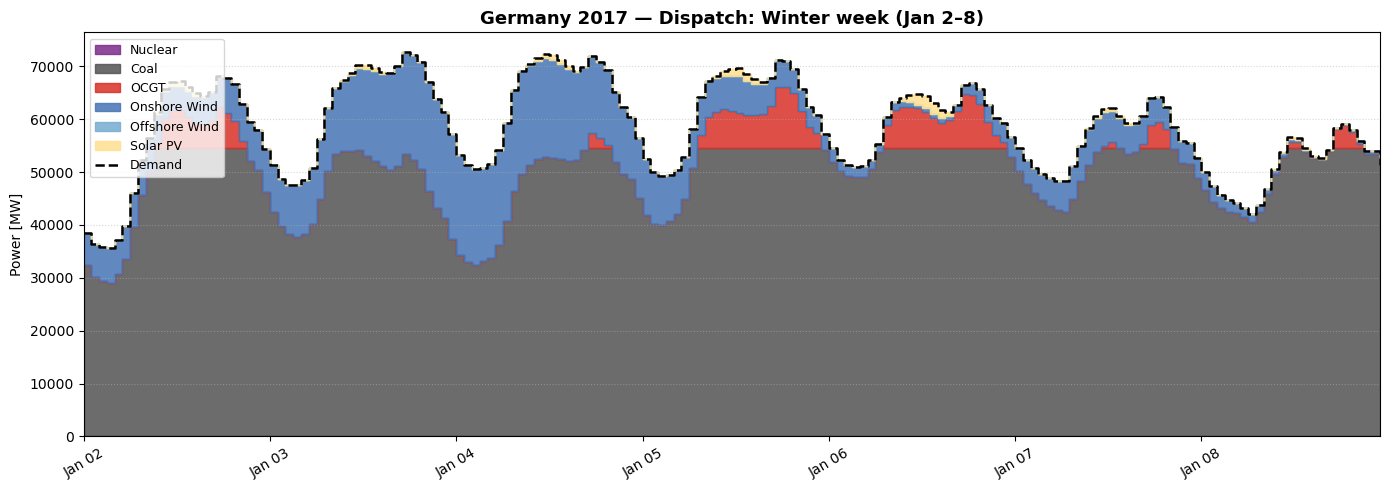

  Saved: dispatch_winter_week.png
Plotting summer dispatch week...


<Figure size 640x480 with 0 Axes>

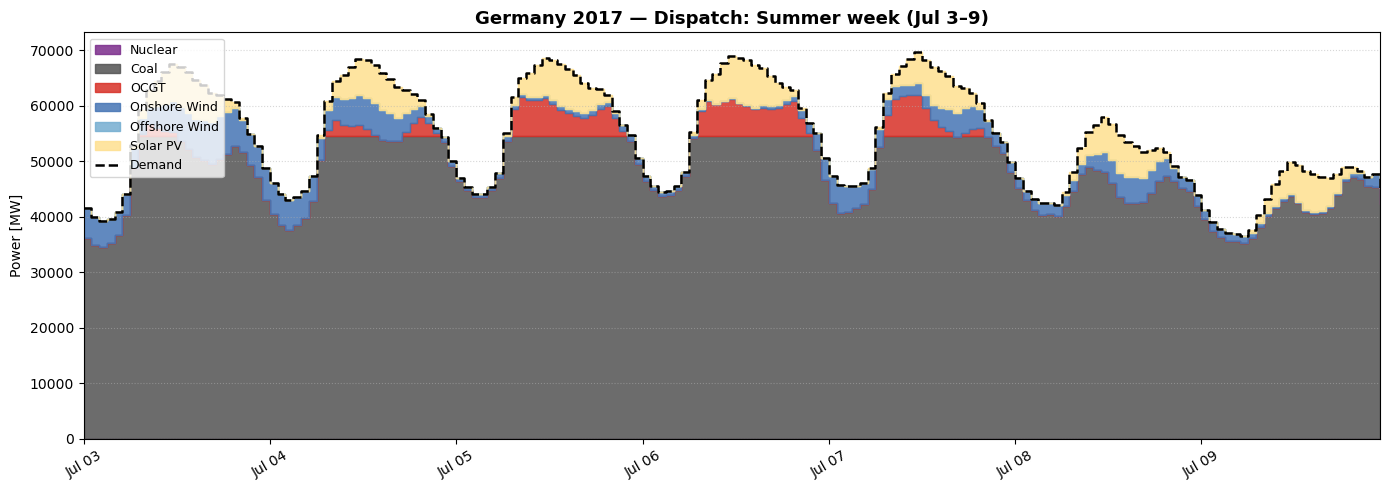

  Saved: dispatch_summer_week.png


<Figure size 640x480 with 0 Axes>

In [9]:
# ── 8. Dispatch: winter week (first full week of January) ─────────────────────
print("\nPlotting winter dispatch week...")
plot_dispatch_week(n,
                   start="2017-01-02",
                   title="Germany 2017 — Dispatch: Winter week (Jan 2–8)",
                   filename="dispatch_winter_week.png")

# ── 9. Dispatch: summer week (first full week of July) ───────────────────────
print("Plotting summer dispatch week...")
plot_dispatch_week(n,
                   start="2017-07-03",
                   title="Germany 2017 — Dispatch: Summer week (Jul 3–9)",
                   filename="dispatch_summer_week.png")

Plotting battery operation for one winter week...


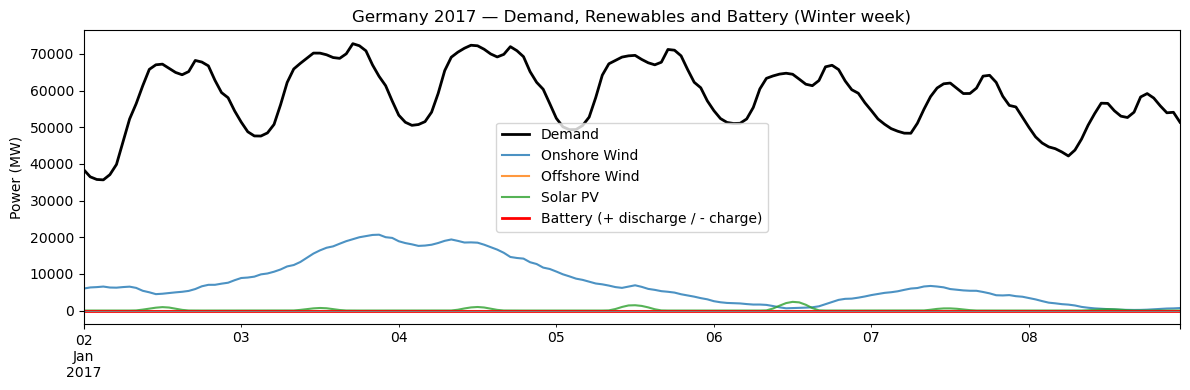

In [10]:
# ── 10. Battery vs demand and renewables: winter week ─────────────────────────
print("Plotting battery operation for one winter week...")

week = slice("2017-01-02", "2017-01-08 23:00")

plt.figure(figsize=(12, 4))

# Demand
n.loads_t.p.loc[week, "demand"].plot(label="Demand", color="black", linewidth=2)

# Renewables
n.generators_t.p.loc[week, "Onshore Wind"].plot(label="Onshore Wind", alpha=0.8)
n.generators_t.p.loc[week, "Offshore Wind"].plot(label="Offshore Wind", alpha=0.8)
n.generators_t.p.loc[week, "Solar PV"].plot(label="Solar PV", alpha=0.8)

# Battery
n.storage_units_t.p.loc[week, "battery"].plot(
    label="Battery (+ discharge / - charge)",
    color="red",
    linewidth=2
)

plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Germany 2017 — Demand, Renewables and Battery (Winter week)")
plt.ylabel("Power (MW)")
plt.xlabel("")
plt.legend()
plt.tight_layout()
plt.show()

Plotting day with strongest battery activity: 2017-01-01


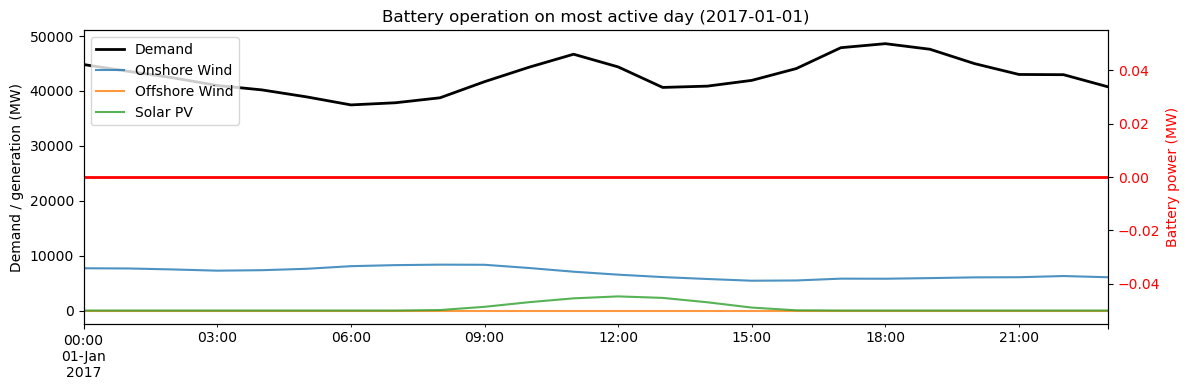

In [11]:
# ── Plot a day with strong battery activity, with battery on secondary axis ──
battery = n.storage_units_t.p["battery"]
active_hour = battery.abs().idxmax()

day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Plotting day with strongest battery activity: {day_start.date()}")

fig, ax1 = plt.subplots(figsize=(12, 4))

# Main axis: demand and renewables
n.loads_t.p.loc[day_start:day_end, "demand"].plot(
    ax=ax1, label="Demand", color="black", linewidth=2
)
n.generators_t.p.loc[day_start:day_end, "Onshore Wind"].plot(
    ax=ax1, label="Onshore Wind", alpha=0.8
)
n.generators_t.p.loc[day_start:day_end, "Offshore Wind"].plot(
    ax=ax1, label="Offshore Wind", alpha=0.8
)
n.generators_t.p.loc[day_start:day_end, "Solar PV"].plot(
    ax=ax1, label="Solar PV", alpha=0.8
)

ax1.set_ylabel("Demand / generation (MW)")
ax1.set_xlabel("")
ax1.legend(loc="upper left")

# Secondary axis: battery
ax2 = ax1.twinx()
battery.loc[day_start:day_end].plot(
    ax=ax2,
    label="Battery",
    color="red",
    linewidth=2,
    drawstyle="steps-mid",
)
ax2.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Battery power (MW)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title(f"Battery operation on most active day ({day_start.date()})")
plt.tight_layout()
plt.show()

Most active summer battery day: 2017-06-01


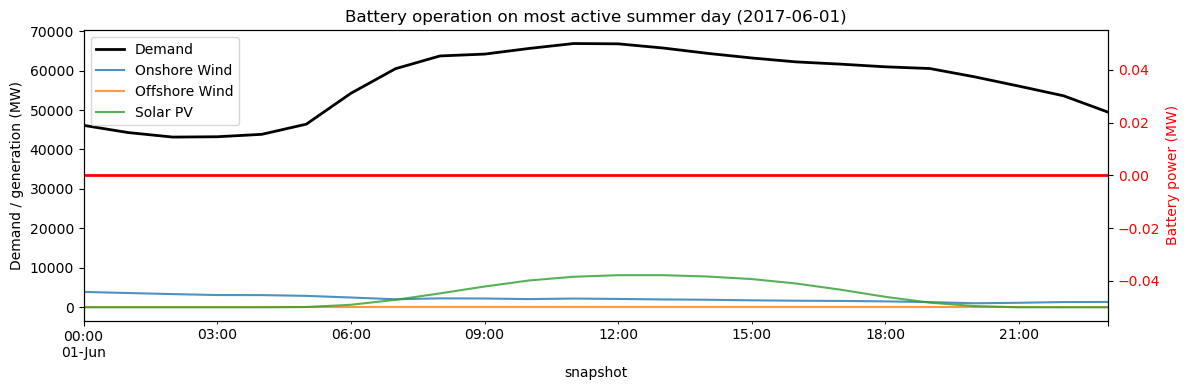

In [12]:
# ── Find most active battery day in summer (Jun-Aug) ────────────────────────
battery_summer = n.storage_units_t.p.loc["2017-06-01":"2017-08-31", "battery"]
active_hour = battery_summer.abs().idxmax()

day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Most active summer battery day: {day_start.date()}")

fig, ax1 = plt.subplots(figsize=(12, 4))

n.loads_t.p.loc[day_start:day_end, "demand"].plot(
    ax=ax1, label="Demand", color="black", linewidth=2
)
n.generators_t.p.loc[day_start:day_end, "Onshore Wind"].plot(
    ax=ax1, label="Onshore Wind", alpha=0.8
)
n.generators_t.p.loc[day_start:day_end, "Offshore Wind"].plot(
    ax=ax1, label="Offshore Wind", alpha=0.8
)
n.generators_t.p.loc[day_start:day_end, "Solar PV"].plot(
    ax=ax1, label="Solar PV", alpha=0.8
)

ax1.set_ylabel("Demand / generation (MW)")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
n.storage_units_t.p.loc[day_start:day_end, "battery"].plot(
    ax=ax2,
    color="red",
    linewidth=2,
    drawstyle="steps-mid",
)
ax2.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Battery power (MW)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title(f"Battery operation on most active summer day ({day_start.date()})")
plt.tight_layout()
plt.show()

Plotting battery-price diagnostic for 2017-01-01


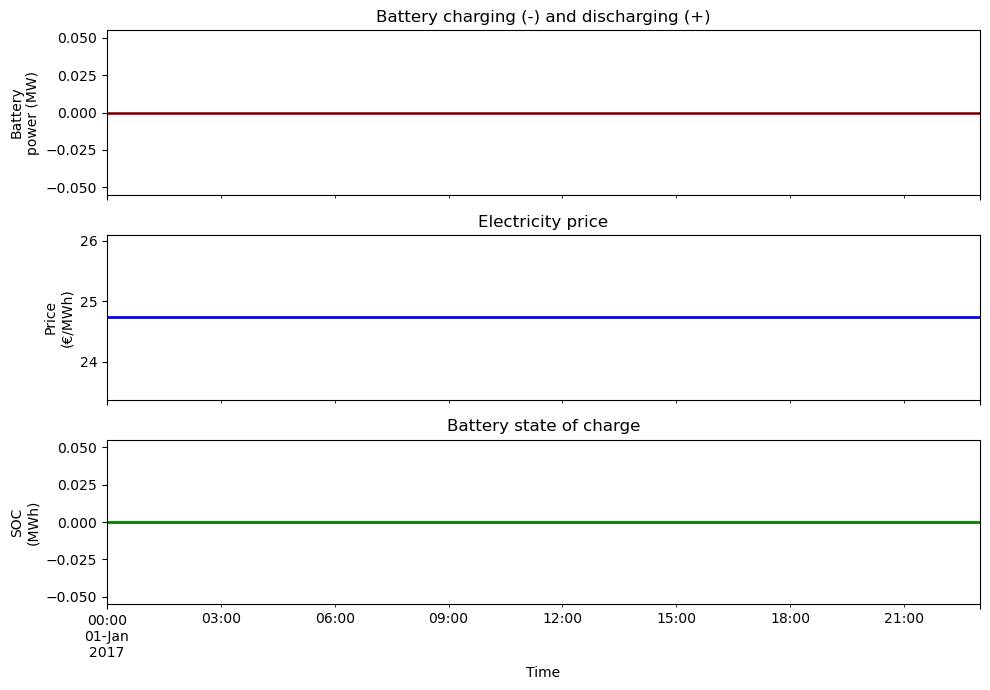

In [14]:
# ── Diagnostic plot: battery vs electricity price ────────────────────────────
battery = n.storage_units_t.p["battery"]
price = n.buses_t.marginal_price["DE electricity"]
soc = n.storage_units_t.state_of_charge["battery"]

# find day with strongest battery activity
active_hour = battery.abs().idxmax()
day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Plotting battery-price diagnostic for {day_start.date()}")

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

# 1) Battery charging/discharging
battery.loc[day_start:day_end].plot(
    ax=axes[0], color="red", linewidth=2, drawstyle="steps-mid"
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Battery\npower (MW)")
axes[0].set_title("Battery charging (-) and discharging (+)")

# 2) Electricity price
price.loc[day_start:day_end].plot(
    ax=axes[1], color="blue", linewidth=2, drawstyle="steps-mid"
)
axes[1].set_ylabel("Price\n(€/MWh)")
axes[1].set_title("Electricity price")

# 3) State of charge
soc.loc[day_start:day_end].plot(
    ax=axes[2], color="green", linewidth=2, drawstyle="steps-mid"
)
axes[2].set_ylabel("SOC\n(MWh)")
axes[2].set_title("Battery state of charge")
axes[2].set_xlabel("Time")

plt.tight_layout()
plt.show()

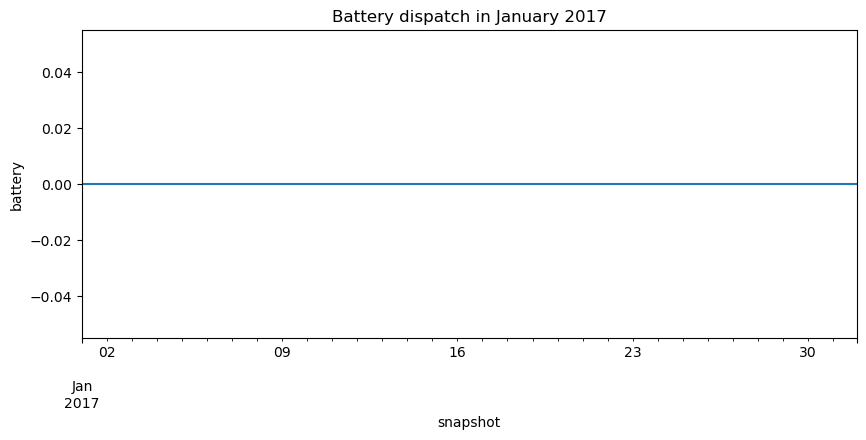

In [13]:
plt.figure(figsize=(10,4))
n.storage_units_t.p["battery"].loc["2017-01"].plot()
plt.ylabel("battery")
plt.xlabel("snapshot")
plt.title("Battery dispatch in January 2017")
plt.show()

Plotting battery behaviour on 2017-01-01


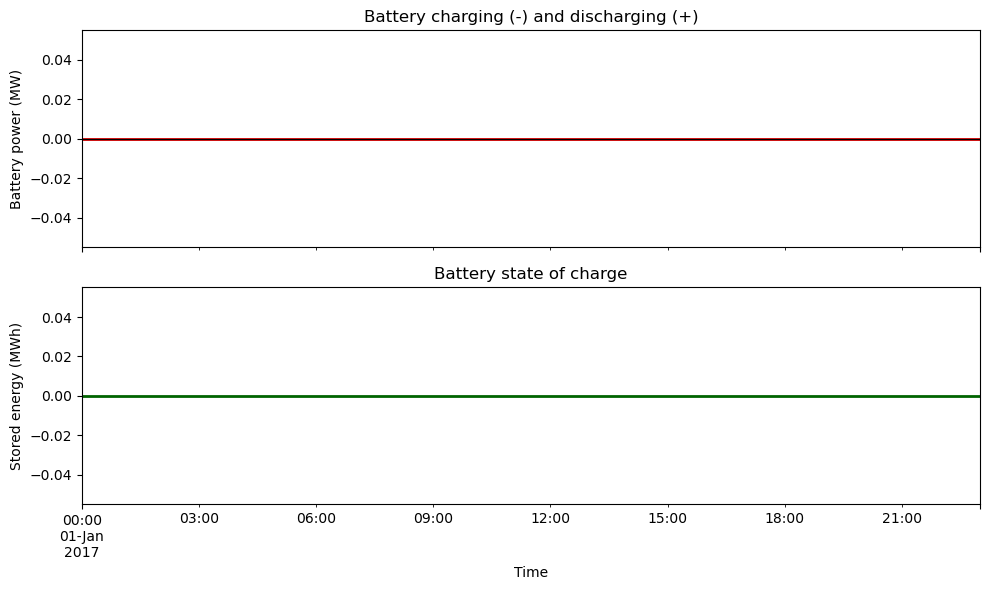

In [15]:
# ── Clean battery operation plot (1 day) ─────────────────────────────────────
battery = n.storage_units_t.p["battery"]
soc = n.storage_units_t.state_of_charge["battery"]

# find day with strongest activity
active_hour = battery.abs().idxmax()
day_start = active_hour.normalize()
day_end = day_start + pd.Timedelta(hours=23)

print(f"Plotting battery behaviour on {day_start.date()}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,6), sharex=True)

# Charging / discharging
battery.loc[day_start:day_end].plot(
    ax=ax1,
    color="red",
    linewidth=2,
    drawstyle="steps-mid"
)
ax1.axhline(0, color="black", linewidth=1)
ax1.set_ylabel("Battery power (MW)")
ax1.set_title("Battery charging (-) and discharging (+)")

# State of charge
soc.loc[day_start:day_end].plot(
    ax=ax2,
    color="darkgreen",
    linewidth=2,
    drawstyle="steps-mid"
)
ax2.set_ylabel("Stored energy (MWh)")
ax2.set_title("Battery state of charge")

plt.xlabel("Time")
plt.tight_layout()
plt.show()

Plotting annual electricity mix...


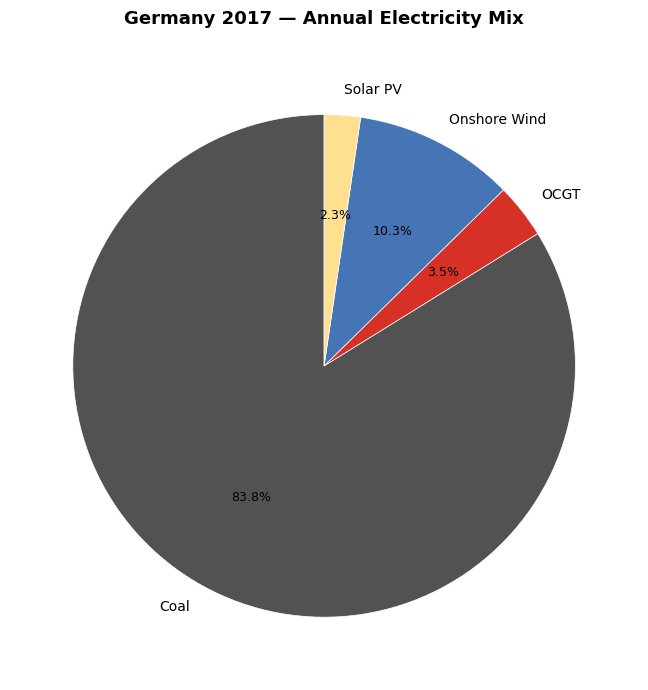

  Saved: electricity_mix.png


In [16]:
# ── 10. Annual electricity mix (pie chart) ────────────────────────────────────
print("Plotting annual electricity mix...")
mix = {tech: n.generators_t.p[tech].sum()
       for tech in TECH_ORDER if tech in n.generators_t.p.columns}
mix = {k: v for k, v in mix.items() if v > 1}  # drop zero-dispatch techs

fig, ax = plt.subplots(figsize=(7, 7))
wedge_colors = [COLORS[k] for k in mix]
wedges, texts, autotexts = ax.pie(
    list(mix.values()),
    labels=list(mix.keys()),
    colors=wedge_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=90,
    wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Germany 2017 — Annual Electricity Mix", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("electricity_mix.png", dpi=150)
plt.show()
print("  Saved: electricity_mix.png")

Plotting duration curves...


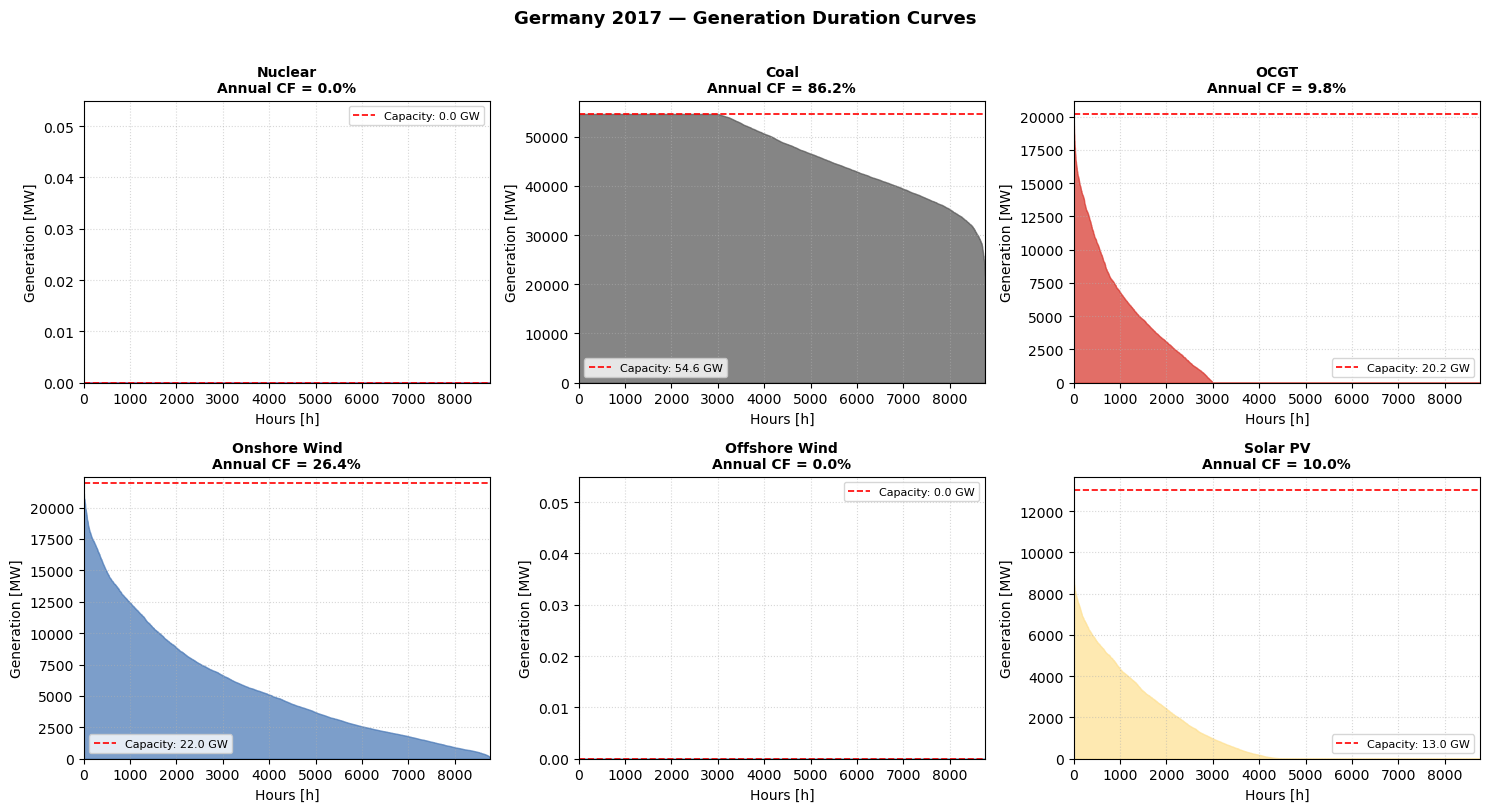

  Saved: duration_curves.png


In [17]:
# ── 11. Duration curves ───────────────────────────────────────────────────────
print("Plotting duration curves...")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, tech in enumerate(TECH_ORDER):
    ax = axes[i]
    if tech not in n.generators_t.p.columns:
        ax.set_visible(False)
        continue

    gen_series = n.generators_t.p[tech]
    cap = n.generators.loc[tech, "p_nom_opt"]

    # Duration curve (sorted generation, descending)
    sorted_gen = np.sort(gen_series.values)[::-1]
    hours = np.arange(1, len(sorted_gen) + 1)

    ax.fill_between(hours, sorted_gen, color=COLORS[tech], alpha=0.7)
    ax.axhline(cap, color="red", linestyle="--", linewidth=1.2, label=f"Capacity: {cap/1000:.1f} GW")

    # Capacity factor annotation
    cf_annual = gen_series.sum() / (cap * len(gen_series)) if cap > 0 else 0
    ax.set_title(f"{tech}\nAnnual CF = {cf_annual:.1%}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Hours [h]")
    ax.set_ylabel("Generation [MW]")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 8760)
    ax.set_ylim(0)
    ax.grid(linestyle=":", alpha=0.5)

plt.suptitle("Germany 2017 — Generation Duration Curves", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("duration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: duration_curves.png")

Plotting capacity factor summary...


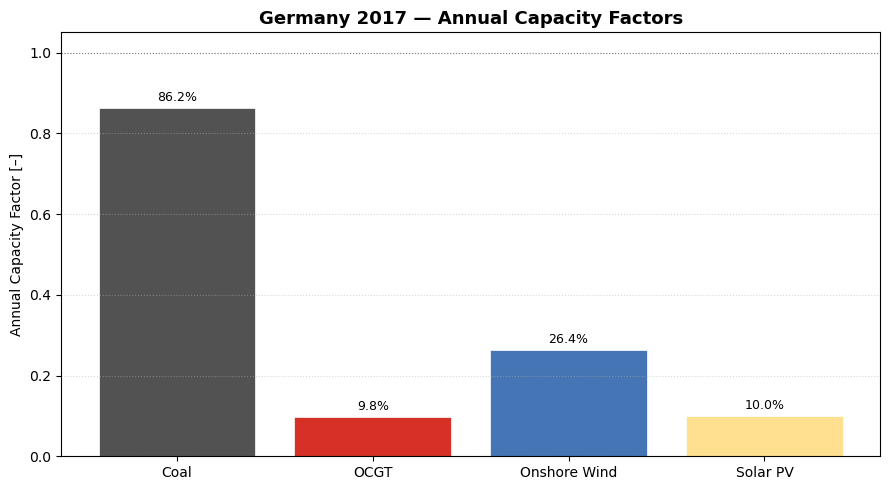

  Saved: capacity_factors.png


In [51]:
# ── 12. Capacity factor bar chart ─────────────────────────────────────────────
print("Plotting capacity factor summary...")
cf_data = {}
for tech in TECH_ORDER:
    if tech in n.generators_t.p.columns:
        cap = n.generators.loc[tech, "p_nom_opt"]
        if cap > 0:
            cf_data[tech] = n.generators_t.p[tech].sum() / (cap * 8760)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [COLORS[t] for t in cf_data]
bars = ax.bar(list(cf_data.keys()), list(cf_data.values()),
              color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_ylabel("Annual Capacity Factor [–]")
ax.set_title("Germany 2017 — Annual Capacity Factors", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="grey", linestyle=":", linewidth=0.8)
for bar, val in zip(bars, cf_data.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("capacity_factors.png", dpi=150)
plt.show()
print("  Saved: capacity_factors.png")

In [52]:
# ── 13. Summary table ─────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Technology':<18} {'Cap [GW]':>10} {'Gen [TWh]':>11} {'CF [%]':>8} {'MC [€/MWh]':>12}")
print("-"*70)
for tech in TECH_ORDER:
    if tech in n.generators_t.p.columns:
        cap = n.generators.loc[tech, "p_nom_opt"] / 1000  # GW
        gen = n.generators_t.p[tech].sum() / 1e6           # TWh
        cf  = (gen * 1e6) / (cap * 1e3 * 8760) if cap > 0 else 0
        mc  = n.generators.loc[tech, "marginal_cost"]
        print(f"  {tech:<16} {cap:>10.2f} {gen:>11.1f} {cf*100:>7.1f}% {mc:>11.2f}")
print("="*70)
print(f"\n  Total annual demand  : {n.loads_t.p['demand'].sum()/1e6:.1f} TWh")
print(f"  System LCOE          : {lcoe:.1f} €/MWh")
print(f"  Total system cost    : {total_cost:.2f} B€/yr")
print("\nAll plots saved. Done!")


Technology           Cap [GW]   Gen [TWh]   CF [%]   MC [€/MWh]
----------------------------------------------------------------------
  Nuclear                0.00         0.0     0.0%       22.61
  Coal                  54.60       412.5    86.2%       24.73
  OCGT                  20.21        17.3     9.8%       55.38
  Onshore Wind          21.95        50.8    26.4%        0.00
  Offshore Wind          0.00         0.0     0.0%        0.00
  Solar PV              13.03        11.4    10.0%        0.00

  Total annual demand  : 492.1 TWh
  System LCOE          : 44.8 €/MWh
  Total system cost    : 22.05 B€/yr

All plots saved. Done!
